# Graph-Spin Model Workflow

**Model.** This notebook creates an arbitrary four-site spin-$1/2$ graph with mixed-axis Pauli interactions and site-resolved fields, then reconstructs matching dense and sparse Hamiltonians from one portable specification.

**Typical uses.** Prototyping non-chain spin geometries, recording mixed-axis couplings, validating sparse construction, visualizing interaction semantics, and evaluating observables without adding a named model builder.

**Parameters.** `SpinInteraction` specifies source and target sites, one Pauli axis per site, and a coefficient. `SpinField` specifies an onsite axis and coefficient. Positions and labels are portable lattice data.

**Useful plots.** The interaction graph shows physical connectivity and labels, while correlation matrices summarize the exact ground state.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from quantum_lattice_models import (
    SpinField,
    SpinInteraction,
    create_graph_spin_spec,
    site_magnetization_z,
    spin_correlation_matrix,
)
from quantum_lattice_models.plotting import plot_interaction_graph
from quantum_lattice_models.spectra import ground_state

In [2]:
model = create_graph_spin_spec(
    4,
    interactions=(
        SpinInteraction(0, 1, "X", "Y", 0.35),
        SpinInteraction(1, 2, "Z", "Z", -0.8),
        SpinInteraction(2, 3, "Y", "X", 0.25),
        SpinInteraction(3, 0, "Z", "X", 0.4),
    ),
    fields=(SpinField(0, "X", -0.3), SpinField(2, "Z", 0.2)),
    positions=((0.0, 0.0), (1.0, 0.0), (1.0, 1.0), (0.0, 1.0)),
    site_labels=("A", "B", "C", "D"),
)
dense = model.hamiltonian()
sparse = model.hamiltonian(sparse=True)

print("Graph-spin construction")
print(f"  matrix shape: {dense.shape}")
print(f"  interaction terms: {len(model.interactions)}")
print(f"  dense/sparse agree: {np.allclose(dense, sparse.toarray())}")
print(f"  labels: {[degree.label for degree in model.local_degrees]}")

Graph-spin construction
  matrix shape: (16, 16)
  interaction terms: 6
  dense/sparse agree: True
  labels: ['A', 'B', 'C', 'D']


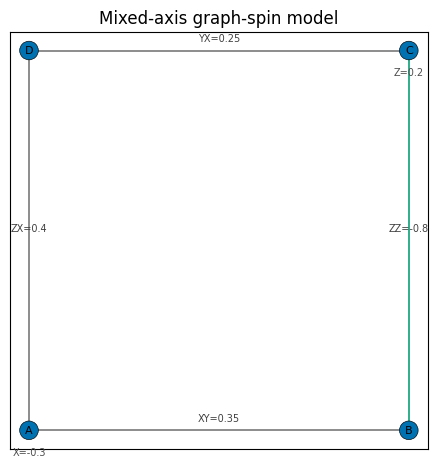

In [3]:
ax = plot_interaction_graph(model, show_coefficients=True)
ax.set_title("Mixed-axis graph-spin model")
ax.figure.tight_layout()

In [4]:
energy, state = ground_state(sparse)
magnetization = site_magnetization_z(state, 4)
correlations = spin_correlation_matrix(state, 4, axis="Z", connected=True)

print("Ground-state observables")
print(f"  energy: {energy:.6f}")
print(f"  site magnetization: {np.array2string(magnetization, precision=4)}")
print(f"  maximum connected |ZZ|: {np.max(np.abs(correlations)):.6f}")

Ground-state observables
  energy: -1.799122
  site magnetization: [ 3.8858e-16 -9.0364e-01 -9.7476e-01 -9.7476e-01]
  maximum connected |ZZ|: 1.000000


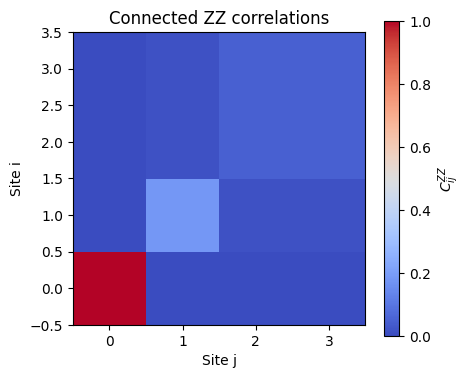

In [5]:
fig, ax = plt.subplots(figsize=(4.8, 4.0))
image = ax.imshow(correlations, cmap="coolwarm", origin="lower")
ax.set_xlabel("Site j")
ax.set_ylabel("Site i")
ax.set_title("Connected ZZ correlations")
fig.colorbar(image, ax=ax, label=r"$C_{ij}^{ZZ}$")
fig.tight_layout()